🚕 Predicting Uber Ride Cancellations

Domain: Urban Mobility & Ride-Hailing Analytics

🎯 Objective

Build a predictive model to determine whether a customer will cancel a ride before it begins, using only the booking metadata available at the time of booking.
The goal is to help the platform proactively identify high-risk cancellations and optimize driver dispatch efficiency.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from xgboost import plot_importance

pd.set_option('display.max_columns', None)


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
df = pd.read_csv('/Users/shubh/Downloads/Capstone/Git/data/ncr_ride_bookings.csv')

In [ ]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

Avg VTAT:	Average time for driver to reach pickup location (in minutes)

Avg CTAT:	Average trip duration from pickup to destination (in minutes)

In [ ]:
# Combine 'Date' and 'Time' into a single datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Drop original columns if not needed
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [ ]:
# Verify the change
print(df.info())
print(df[['datetime']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Booking ID                         150000 non-null  object        
 1   Booking Status                     150000 non-null  object        
 2   Customer ID                        150000 non-null  object        
 3   Vehicle Type                       150000 non-null  object        
 4   Pickup Location                    150000 non-null  object        
 5   Drop Location                      150000 non-null  object        
 6   Avg VTAT                           139500 non-null  float64       
 7   Avg CTAT                           102000 non-null  float64       
 8   Cancelled Rides by Customer        10500 non-null   float64       
 9   Reason for cancelling by Customer  10500 non-null   object        
 10  Cancelled Rides by D

In [ ]:
df.head()

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime
0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38
1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39
2,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10
3,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25
4,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00


In [ ]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['weekday'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

In [ ]:
df.head()

/Users/shubh/.pyenv/versions/3.11.3/lib/python3.11/site-packages/IPython/core/displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend
0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True
1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False
2,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False
3,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False
4,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False


In [ ]:
df['Vehicle Type'].unique()

array(['eBike', 'Go Sedan', 'Auto', 'Premier Sedan', 'Bike', 'Go Mini',
       'Uber XL'], dtype=object)

In [ ]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [ ]:
df[df['Avg VTAT'].isnull()].head()

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend
0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True
8,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-14 12:49:09,12,Saturday,5,9,True
11,"""CNR9551927""",No Driver Found,"""CID7568143""",Auto,Vidhan Sabha,AIIMS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-18 08:09:38,8,Wednesday,2,9,False
27,"""CNR4499383""",No Driver Found,"""CID5717521""",Premier Sedan,Sadar Bazar Gurgaon,Mehrauli,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-12 19:42:35,19,Friday,4,4,False
57,"""CNR9773309""",No Driver Found,"""CID9965847""",Uber XL,Anand Vihar ISBT,Dwarka Sector 21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-11 15:43:34,15,Thursday,3,4,False


In [ ]:
df[df['Avg VTAT'].isnull()]['Booking Status'].unique()

array(['No Driver Found'], dtype=object)

In [ ]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [ ]:
df['Reason for cancelling by Customer'].unique() 

array([nan, 'Driver is not moving towards pickup location',
       'Driver asked to cancel', 'AC is not working', 'Change of plans',
       'Wrong Address'], dtype=object)

In [ ]:
df[df['Booking Status']=='Incomplete'].head()

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend
1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False
9,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,NaN,NaN,NaN,NaN,1.0,Other Issue,135.0,10.36,NaN,NaN,Cash,2024-12-16 19:06:48,19,Monday,0,12,False
28,"""CNR9834201""",Incomplete,"""CID7891331""",Bike,Shastri Park,Botanical Garden,3.1,28.2,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,304.0,1.98,NaN,NaN,UPI,2024-04-05 18:57:12,18,Friday,4,4,False
42,"""CNR4130953""",Incomplete,"""CID3196782""",Premier Sedan,Panipat,Tagore Garden,6.4,10.5,NaN,NaN,NaN,NaN,1.0,Other Issue,966.0,18.30,NaN,NaN,Debit Card,2024-02-12 19:42:39,19,Monday,0,2,False
47,"""CNR4674790""",Incomplete,"""CID4795905""",Bike,Dilshad Garden,Nehru Place,2.3,29.7,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,453.0,19.24,NaN,NaN,Debit Card,2024-09-30 13:10:50,13,Monday,0,9,False


In [ ]:
df[df['Booking Status']=='Incomplete']['Incomplete Rides Reason'].unique()

array(['Vehicle Breakdown', 'Other Issue', 'Customer Demand'],
      dtype=object)

In [ ]:
df[df['Cancelled Rides by Customer']==1]['Booking Status'].unique()

array(['Cancelled by Customer'], dtype=object)

In [ ]:
# Cancelled Rides by Customer vs Booking Status 
pd.crosstab(df['Booking Status'], df['Cancelled Rides by Customer'], dropna=False)

Cancelled Rides by Customer,1.0,NaN
Booking Status,,
Cancelled by Customer,10500,0
Cancelled by Driver,0,27000
Completed,0,93000
Incomplete,0,9000
No Driver Found,0,10500


In [ ]:
# Cancelled Rides by Driver vs Booking Status 
pd.crosstab(df['Booking Status'], df['Cancelled Rides by Driver'], dropna=False)

Cancelled Rides by Driver,1.0,NaN
Booking Status,,
Cancelled by Customer,0,10500
Cancelled by Driver,27000,0
Completed,0,93000
Incomplete,0,9000
No Driver Found,0,10500


In [ ]:
# filling NaN as O "not cancelled"
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0).astype(int)
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0).astype(int)
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0).astype(int)

In [ ]:
# Create binary flags from cancellation/incomplete columns
#df['is_cancelled_customer'] = df['Cancelled Rides by Customer'].notnull()
#df['is_cancelled_driver'] = df['Cancelled Rides by Driver'].notnull()
#df['is_incomplete'] = df['Incomplete Rides'].notnull()

# Create a flag for missing ratings and booking values
df['missing_driver_rating'] = df['Driver Ratings'].isnull().astype(int)
df['missing_customer_rating'] = df['Customer Rating'].isnull().astype(int)
df['missing_booking_value'] = df['Booking Value'].isnull().astype(int)
df['missing_payment_method'] = df['Payment Method'].isnull().astype(int)

In [ ]:
df['Cancelled Rides by Customer'].unique()

array([0, 1])

In [ ]:
df['Cancelled Rides by Driver'].unique()

array([0, 1])

In [ ]:
df['Booking ID'].nunique()

148767

In [ ]:
len(df)

150000

In [ ]:
print(df['Booking ID'].isnull().sum())
print(df['Customer ID'].isnull().sum())

0
0


In [ ]:
dup_mask = df['Booking ID'].duplicated(keep='first')
print("duplicate rows (excluding first):", dup_mask.sum())
df[dup_mask].head()


duplicate rows (excluding first): 1233


,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
5522,"""CNR5071968""",No Driver Found,"""CID6309096""",Auto,Kanhaiya Nagar,India Gate,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-10 19:55:06,19,Sunday,6,3,True,1,1,1,1
7762,"""CNR8512595""",Completed,"""CID9741888""",Go Mini,Narsinghpur,Huda City Centre,3.5,15.4,0,NaN,0,NaN,0,NaN,187.0,41.45,4.4,4.2,Credit Card,2024-03-01 11:55:56,11,Friday,4,3,False,0,0,0,0
9587,"""CNR1029172""",Completed,"""CID6382731""",Auto,Inderlok,Laxmi Nagar,6.9,34.4,0,NaN,0,NaN,0,NaN,332.0,36.38,4.3,4.3,UPI,2024-12-17 19:19:02,19,Tuesday,1,12,False,0,0,0,0
9726,"""CNR7132372""",Completed,"""CID6950827""",Go Sedan,Kalkaji,Sushant Lok,3.8,18.3,0,NaN,0,NaN,0,NaN,389.0,44.95,3.7,4.2,UPI,2024-05-23 20:44:27,20,Thursday,3,5,False,0,0,0,0
10186,"""CNR7768664""",Completed,"""CID4473762""",eBike,Anand Vihar ISBT,Netaji Subhash Place,5.1,42.1,0,NaN,0,NaN,0,NaN,357.0,17.03,4.2,4.2,UPI,2024-12-14 21:15:59,21,Saturday,5,12,True,0,0,0,0


In [ ]:
df[df['Booking ID']=='"CNR5071968"']

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
317,"""CNR5071968""",Completed,"""CID7384045""",Go Sedan,Panchsheel Park,Yamuna Bank,4.7,42.5,0,NaN,0,NaN,0,NaN,473.0,48.35,4.7,3.8,Cash,2024-10-10 03:56:19,3,Thursday,3,10,False,0,0,0,0
5522,"""CNR5071968""",No Driver Found,"""CID6309096""",Auto,Kanhaiya Nagar,India Gate,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-10 19:55:06,19,Sunday,6,3,True,1,1,1,1


In [ ]:
df[df['Booking ID']=='"CNR8512595"']

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
1893,"""CNR8512595""",Completed,"""CID8017027""",Auto,Ashok Vihar,Mehrauli,14.6,29.6,0,NaN,0,NaN,0,NaN,294.0,44.22,3.6,5.0,Cash,2024-11-02 10:45:25,10,Saturday,5,11,True,0,0,0,0
7762,"""CNR8512595""",Completed,"""CID9741888""",Go Mini,Narsinghpur,Huda City Centre,3.5,15.4,0,NaN,0,NaN,0,NaN,187.0,41.45,4.4,4.2,Credit Card,2024-03-01 11:55:56,11,Friday,4,3,False,0,0,0,0


In [ ]:
# create missing flags and impute Avg VTAT / Avg CTAT by median per Vehicle Type (fallback to global median)
df['Avg_VTAT_missing'] = df['Avg VTAT'].isnull().astype(int)
df['Avg_CTAT_missing'] = df['Avg CTAT'].isnull().astype(int)

# median per vehicle type, then fallback to overall median if vehicle-type median is NaN
vtat_med_by_type = df.groupby(['Vehicle Type','Pickup Location'])['Avg VTAT'].transform('median')
ctat_med_by_type = df.groupby(['Vehicle Type','Pickup Location'])['Avg CTAT'].transform('median')

df['Avg_VTAT_imputed'] = df['Avg VTAT'].fillna(vtat_med_by_type).fillna(df['Avg VTAT'].median())
df['Avg_CTAT_imputed'] = df['Avg CTAT'].fillna(ctat_med_by_type).fillna(df['Avg CTAT'].median())

# Optional: drop or keep original columns. Defaults keep both original and imputed.
# df.drop(['Avg VTAT','Avg CTAT'], axis=1, inplace=True)  # uncomment if you want to replace originals

In [ ]:
df.head()

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed
0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True,1,1,1,1,1,1,9.7,28.15
1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False,1,1,0,0,0,0,4.9,14.00
2,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False,0,0,0,0,0,0,13.4,25.80
3,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False,0,0,0,0,0,0,13.1,28.50
4,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False,0,0,0,0,0,0,5.3,19.60


In [ ]:
# df1= df.drop('Booking ID', axis=1)
# df1.head()

In [ ]:
df.duplicated().sum()  # check for duplicate rows

np.int64(0)

In [ ]:
df.describe() 

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating,datetime,hour,weekday,month,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed
count,139500.000000,102000.000000,150000.000000,150000.000000,150000.000000,102000.000000,102000.000000,93000.000000,93000.000000,150000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,8.456352,29.149636,0.070000,0.180000,0.060000,508.295912,24.637012,4.230992,4.404584,2024-07-01 07:14:41.251033344,14.034113,2.996987,6.490940,0.380000,0.380000,0.320000,0.320000,0.070000,0.320000,8.442259,29.042137
min,2.000000,10.000000,0.000000,0.000000,0.000000,50.000000,1.000000,3.000000,3.000000,2024-01-01 00:19:34,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000
25%,5.300000,21.600000,0.000000,0.000000,0.000000,234.000000,12.460000,4.100000,4.200000,2024-03-31 22:55:36.249999872,10.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.600000,24.900000
50%,8.300000,28.800000,0.000000,0.000000,0.000000,414.000000,23.720000,4.300000,4.500000,2024-07-01 09:24:52.500000,15.000000,3.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.250000,28.800000
75%,11.300000,36.800000,0.000000,0.000000,0.000000,689.000000,36.820000,4.600000,4.800000,2024-09-30 13:46:07.249999872,18.000000,5.000000,9.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,11.000000,33.100000
max,20.000000,45.000000,1.000000,1.000000,1.000000,4277.000000,50.000000,5.000000,5.000000,2024-12-30 23:36:11,23.000000,6.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,20.000000,45.000000
std,3.773564,8.902577,0.255148,0.384189,0.237488,395.805774,14.002138,0.436871,0.437819,NaN,5.416906,2.003202,3.444028,0.485388,0.485388,0.466478,0.466478,0.255148,0.466478,3.642278,7.399978


## EDA

3. Exploratory Data Analysis (EDA)

	•	Cancellation patterns: By hour, weekday/weekend, vehicle type, and location.

	•	Customer behavior: Analyze repeat cancellations per customer.

	•	Operational metrics: Impact of higher Avg VTAT (driver arrival time), Avg CTAT(ride time) on cancellations.

Notes:

    •	Ride distance, booking value, customer and driver ratings are null in case of   cancelled rides. So, EDA cannot be done for these variables. They are only populated when are ride is completed.
    	
	•	We could analyse the cancellation ride pattern with ride distance by calculating the distance between the pickup and drop location and with customer or driver ratings by looking at the average ratings on a larger dataset (which we are lacking in this case). However, this is out of our scope in this project.

In [ ]:
df.head()

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed
0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True,1,1,1,1,1,1,9.7,28.15
1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False,1,1,0,0,0,0,4.9,14.00
2,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False,0,0,0,0,0,0,13.4,25.80
3,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False,0,0,0,0,0,0,13.1,28.50
4,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False,0,0,0,0,0,0,5.3,19.60


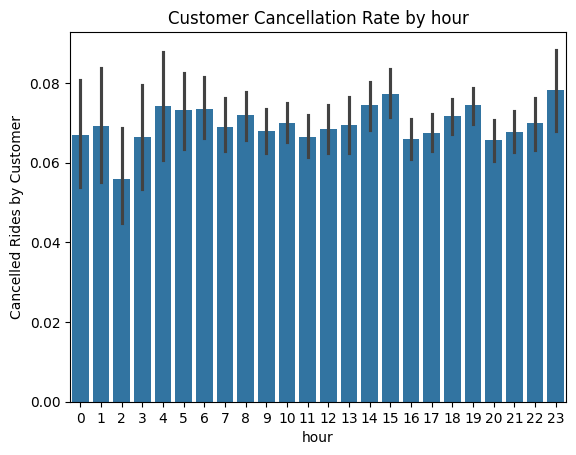

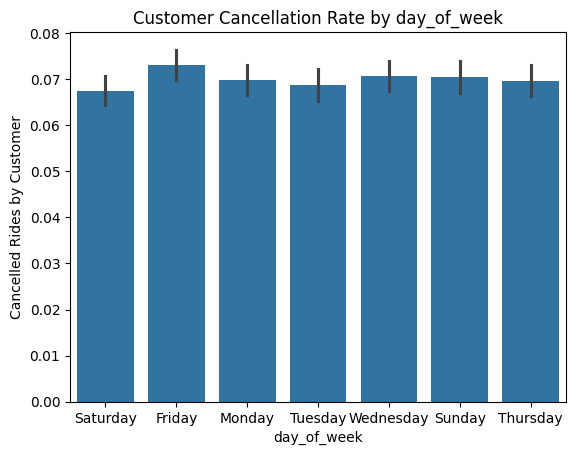

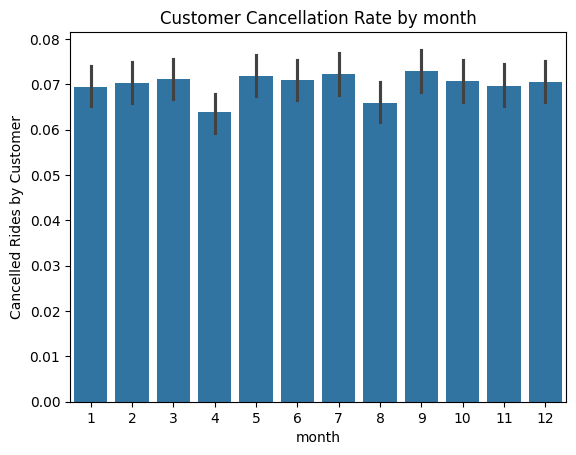

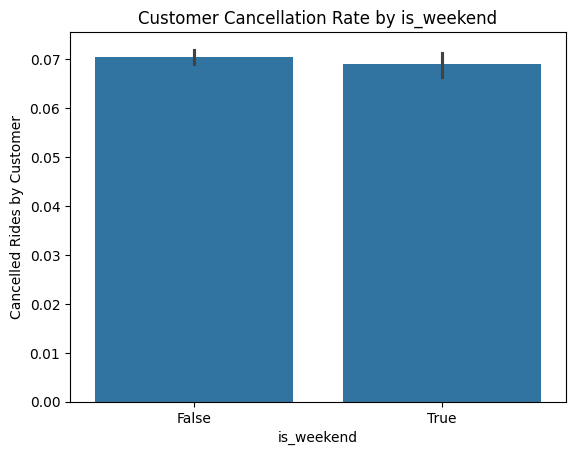

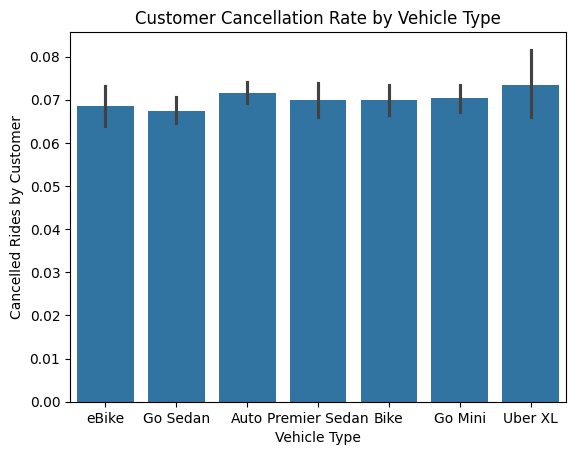

In [ ]:
#hour
for i in ['hour', 'day_of_week', 'month', 'is_weekend', 'Vehicle Type']:
     sns.barplot(x=df[i], y= df['Cancelled Rides by Customer'])
     plt.title(f"Customer Cancellation Rate by {i}")
     plt.show()


# plt.xlabel("Hour of Day")
# plt.ylabel("Average Cancellation Rate")
# plt.show()

1. Customer Cancellation rate (%) is highest at 23:00 and 15:00 hours per day, on Fridays
2. Customer Cancellation rate (%) is lowest in April and August.


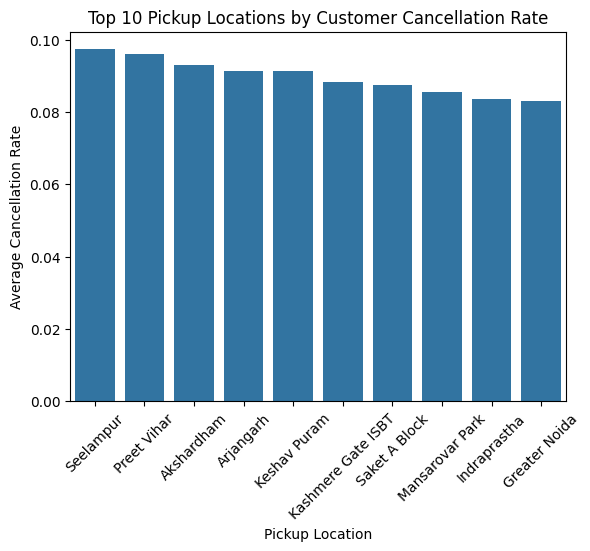

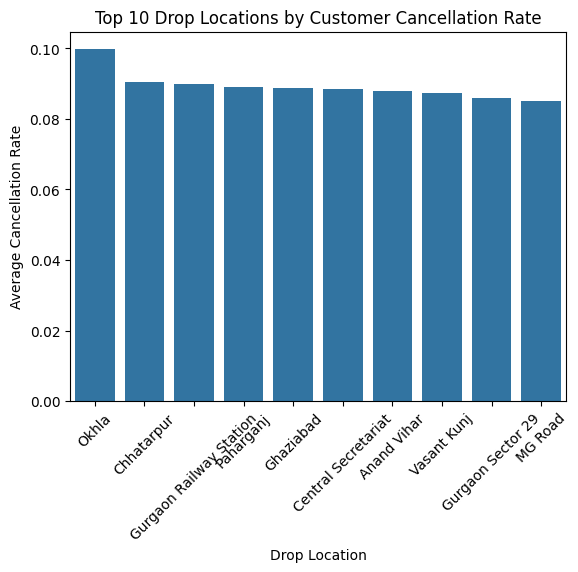

In [ ]:
df_pickup = df.groupby('Pickup Location')['Cancelled Rides by Customer'].mean().sort_values(ascending=False).head(10).reset_index()
df_drop = df.groupby('Drop Location')['Cancelled Rides by Customer'].mean().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x='Pickup Location', y='Cancelled Rides by Customer', data=df_pickup)
plt.title("Top 10 Pickup Locations by Customer Cancellation Rate")
plt.xlabel("Pickup Location")
plt.ylabel("Average Cancellation Rate")
plt.xticks(rotation=45)
plt.show()
sns.barplot(x='Drop Location', y='Cancelled Rides by Customer', data=df_drop)
plt.title("Top 10 Drop Locations by Customer Cancellation Rate")
plt.xlabel("Drop Location")
plt.ylabel("Average Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

# plt.xlabel("Hour of Day")
# plt.ylabel("Average Cancellation Rate")
# plt.show()

1. Customer Cancellation rate (%) is highest from pickup location 'Seelampur' and with drop location 'Okhla'

In [ ]:
df.head()

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed
0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True,1,1,1,1,1,1,9.7,28.15
1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False,1,1,0,0,0,0,4.9,14.00
2,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False,0,0,0,0,0,0,13.4,25.80
3,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False,0,0,0,0,0,0,13.1,28.50
4,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False,0,0,0,0,0,0,5.3,19.60


In [ ]:
# for i in ['Ride Distance', 'Booking Value', 'Driver Ratings', 'Customer Rating']:
#      sns.barplot(x=df[i], y= df['Cancelled Rides by Customer'])
#      plt.title(f"Customer Cancellation Rate by {i}")
#      plt.show()

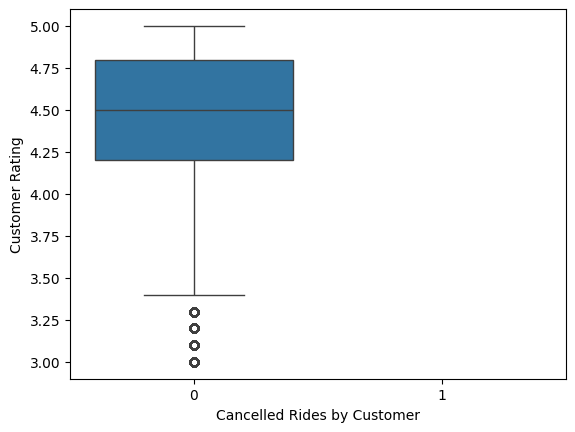

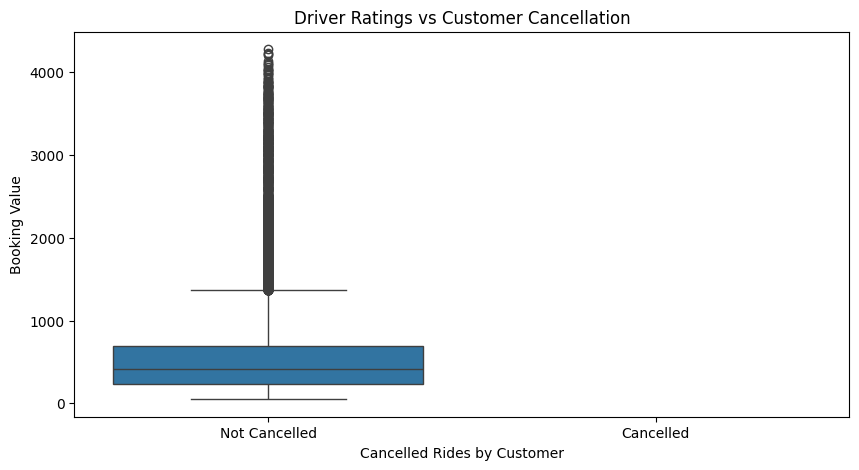

In [ ]:
# sns.barplot(x=df['Ride Distance'], y=df['Cancelled Rides by Customer'])
# plt.title("Customer Cancellation Rate by Ride Distance")
# plt.xlabel("Ride Distance")
# plt.ylabel("Average Cancellation Rate")
# plt.show()

# sns.barplot(x='Booking Value', y='Cancelled Rides by Customer', data=df)
# plt.title("Customer Cancellation Rate by Booking Value")
# plt.xlabel("Booking Value")
# plt.ylabel("Average Cancellation Rate")
# plt.show()

#sns.boxplot(x='Driver Ratings', y='Cancelled Rides by Customer', data=df)
# plt.title("Customer Cancellation Rate by Driver Ratings")
# plt.xlabel("Driver Ratings")
# plt.ylabel("Average Cancellation Rate")
# plt.show()


sns.boxplot(y='Customer Rating', x='Cancelled Rides by Customer', data=df)
# plt.title("Customer Cancellation Rate by Customer Rating")
# plt.xlabel("Customer Rating")
# plt.ylabel("Average Cancellation Rate")
# plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Cancelled Rides by Customer', y='Booking Value')
plt.title("Driver Ratings vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

In [ ]:
df[df['Cancelled Rides by Customer']==1].groupby('Customer ID').size().sort_values(ascending=False).head(10).reset_index()  

,Customer ID,0
0,"""CID8416905""",2
1,"""CID7939117""",2
2,"""CID5251785""",2
3,"""CID5505307""",2
4,"""CID2358909""",2
5,"""CID5488244""",2
6,"""CID8887672""",2
7,"""CID8519067""",2
8,"""CID7079917""",1
9,"""CID7042696""",1


We don't have many repeated customer cancellations. Only 7 customers have cancelled twice. So, there is no pattern of cancelled rides with customer IDs.

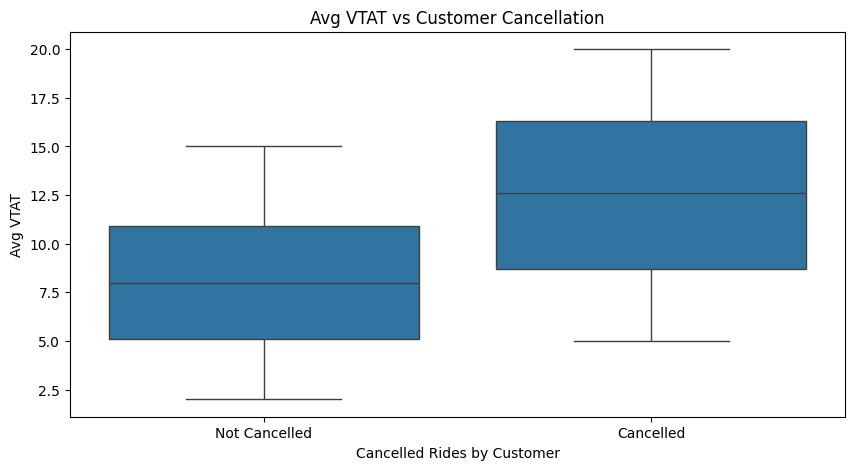

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Cancelled Rides by Customer', y='Avg VTAT')
plt.title("Avg VTAT vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

We can clearly see here that Avg VTAT (driver arrival time) is higher for cancelled rides with a median around 12.5 minutes and for not cancelled rides is around 7.5 minutes. So, Avg VTAT is our key driver that coorelate with customer cancellations.

## Feature Engineering

Enhance predictive power with derived features such as:

- Customer-related: Customer_Cancel_Rate → (Past cancelled rides / total rides per customer)

- Time-based:	Is_Peak_Hour

- Location-based: Encode frequent cancellation zones using clustering or frequency encoding.

- Value-related: Categorize rides by price range or distance bucket.


📈 Output: Feature-enriched dataset that captures behavioral, spatial, and temporal signals.

In [ ]:
# Define peak hours: 7-10 AM and 5-8 PM
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0)
df[['hour','is_peak_hour']].head(10)

,hour,is_peak_hour
0,12,0
1,18,1
2,8,1
3,17,1
4,22,0
5,9,1
6,15,0
7,17,1
8,12,0
9,19,1


In [ ]:
df1 = df.copy()
df1 = pd.get_dummies(df, columns=['Vehicle Type', 'day_of_week'], drop_first=True)
df1.head()

# dummies
# Booking Status, Payment Method

,Booking ID,Booking Status,Customer ID,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed,is_peak_hour,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,"""CNR5884300""",No Driver Found,"""CID1982111""",Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False
1,"""CNR1326809""",Incomplete,"""CID4604802""",Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False
2,"""CNR8494506""",Completed,"""CID9202816""",Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False
3,"""CNR8906825""",Completed,"""CID2610914""",Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False
4,"""CNR1950162""",Completed,"""CID9933542""",Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
df1['Payment Method'] = df1['Payment Method'].fillna('Unknown')
df1 = pd.get_dummies(df1, columns=['Payment Method'], drop_first=True)
df1.head()

,Booking ID,Booking Status,Customer ID,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,datetime,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed,is_peak_hour,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet,Payment Method_Unknown
0,"""CNR5884300""",No Driver Found,"""CID1982111""",Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
1,"""CNR1326809""",Incomplete,"""CID4604802""",Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,2024-11-29 18:01:39,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,"""CNR8494506""",Completed,"""CID9202816""",Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,2024-08-23 08:56:10,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,"""CNR8906825""",Completed,"""CID2610914""",Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,2024-10-21 17:17:25,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False
4,"""CNR1950162""",Completed,"""CID9933542""",Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,2024-09-16 22:08:00,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False



drop


Booking ID, Reason for cancelling by Customer, Driver Cancellation Reason, Cancelled Rides by Driver, Incomplete Rides, Incomplete Rides Reason, datetime, avg Vtat, avg CTAt

In [ ]:
# Encoding Top 10 Pickup Locations by occurrence & customer cancellation
top_pickups = df1['Pickup Location'].value_counts().nlargest(10).index
top_pickups_cus_canc = df1[df1['Cancelled Rides by Customer'] == 1]['Pickup Location'].value_counts().nlargest(10).index
df1['pickup_encoded'] = df1['Pickup Location'].apply(lambda x: x if x in top_pickups else 'Other')
df1['pickup_encoded_cus_canc'] = df1['Pickup Location'].apply(lambda x: x if x in top_pickups_cus_canc else 'Other')
df1 = pd.get_dummies(df1, columns=['pickup_encoded'], prefix='pickup', drop_first=True)
df1 = pd.get_dummies(df1, columns=['pickup_encoded_cus_canc'], prefix='pickup_cus_canc', drop_first=True)

# Encoding Top 10 Drop Locations by occurrence & customer cancellation
top_drops = df1['Drop Location'].value_counts().nlargest(10).index
top_drops_cus_canc = df1[df1['Cancelled Rides by Customer'] == 1]['Drop Location'].value_counts().nlargest(10).index
df1['drop_encoded'] = df1['Drop Location'].apply(lambda x: x if x in top_drops else 'Other')
df1['drop_encoded_cus_canc'] = df1['Drop Location'].apply(lambda x: x if x in top_drops_cus_canc else 'Other')
df1 = pd.get_dummies(df1, columns=['drop_encoded'], prefix='drop', drop_first=True)
df1 = pd.get_dummies(df1, columns=['drop_encoded_cus_canc'], prefix='drop_cus_canc', drop_first=True)
df1.head()

,Booking ID,Booking Status,Customer ID,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,datetime,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed,is_peak_hour,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet,Payment Method_Unknown,pickup_Badarpur,pickup_Barakhamba Road,pickup_Dwarka Sector 21,pickup_Khandsa,pickup_Madipur,pickup_Mehrauli,pickup_Other,pickup_Pataudi Chowk,pickup_Pragati Maidan,pickup_Saket,pickup_cus_canc_Arjangarh,pickup_cus_canc_Badarpur,pickup_cus_canc_Greater Kailash,pickup_cus_canc_Greater Noida,pickup_cus_canc_Kashmere Gate ISBT,pickup_cus_canc_Keshav Puram,pickup_cus_canc_Mansarovar Park,pickup_cus_canc_Other,pickup_cus_canc_Preet Vihar,pickup_cus_canc_Seelampur,drop_Basai Dhankot,drop_Cyber Hub,drop_Kalkaji,drop_Kashmere Gate ISBT,drop_Lajpat Nagar,drop_Lok Kalyan Marg,drop_Narsinghpur,drop_Nehru Place,drop_Other,drop_Udyog Vihar,drop_cus_canc_Bahadurgarh,drop_cus_canc_Central Secretariat,drop_cus_canc_Chhatarpur,drop_cus_canc_Ghaziabad,drop_cus_canc_Gurgaon Railway Station,drop_cus_canc_Kalkaji,drop_cus_canc_Okhla,drop_cus_canc_Other,drop_cus_canc_Paharganj,drop_cus_canc_Uttam Nagar
0,"""CNR5884300""",No Driver Found,"""CID1982111""",Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,"""CNR1326809""",Incomplete,"""CID4604802""",Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,2024-11-29 18:01:39,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,"""CNR8494506""",Completed,"""CID9202816""",Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,2024-08-23 08:56:10,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,"""CNR8906825""",Completed,"""CID2610914""",Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,2024-10-21 17:17:25,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,"""CNR1950162""",Completed,"""CID9933542""",Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,2024-09-16 22:08:00,22,0,9,False,0

In [ ]:
df1 = df1.drop(['Booking ID', 'Booking Status', 'Pickup Location', 'Drop Location', 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 
                'Cancelled Rides by Driver', 'Incomplete Rides', 'Incomplete Rides Reason',
                'datetime', 'Avg VTAT', 'Avg CTAT'], axis=1)
df1.head()

,Customer ID,Cancelled Rides by Customer,Booking Value,Ride Distance,Driver Ratings,Customer Rating,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed,is_peak_hour,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet,Payment Method_Unknown,pickup_Badarpur,pickup_Barakhamba Road,pickup_Dwarka Sector 21,pickup_Khandsa,pickup_Madipur,pickup_Mehrauli,pickup_Other,pickup_Pataudi Chowk,pickup_Pragati Maidan,pickup_Saket,pickup_cus_canc_Arjangarh,pickup_cus_canc_Badarpur,pickup_cus_canc_Greater Kailash,pickup_cus_canc_Greater Noida,pickup_cus_canc_Kashmere Gate ISBT,pickup_cus_canc_Keshav Puram,pickup_cus_canc_Mansarovar Park,pickup_cus_canc_Other,pickup_cus_canc_Preet Vihar,pickup_cus_canc_Seelampur,drop_Basai Dhankot,drop_Cyber Hub,drop_Kalkaji,drop_Kashmere Gate ISBT,drop_Lajpat Nagar,drop_Lok Kalyan Marg,drop_Narsinghpur,drop_Nehru Place,drop_Other,drop_Udyog Vihar,drop_cus_canc_Bahadurgarh,drop_cus_canc_Central Secretariat,drop_cus_canc_Chhatarpur,drop_cus_canc_Ghaziabad,drop_cus_canc_Gurgaon Railway Station,drop_cus_canc_Kalkaji,drop_cus_canc_Okhla,drop_cus_canc_Other,drop_cus_canc_Paharganj,drop_cus_canc_Uttam Nagar
0,"""CID1982111""",0,NaN,NaN,NaN,NaN,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,"""CID4604802""",0,237.0,5.73,NaN,NaN,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,"""CID9202816""",0,627.0,13.58,4.9,4.9,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,"""CID2610914""",0,416.0,34.02,4.6,5.0,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,"""CID9933542""",0,737.0,48.21,4.1,4.3,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False


In [ ]:
booking_value_median = df1['Booking Value'].median()
ride_distance_median = df1['Ride Distance'].median()
driver_rating_median = df1['Driver Ratings'].median()
customer_rating_median = df1['Customer Rating'].median()
df1['Booking Value'] = df1['Booking Value'].fillna(booking_value_median)
df1['Ride Distance'] = df1['Ride Distance'].fillna(ride_distance_median)
df1['Driver Ratings'] = df1['Driver Ratings'].fillna(driver_rating_median)
df1['Customer Rating'] = df1['Customer Rating'].fillna(customer_rating_median)
df1.head()

,Customer ID,Cancelled Rides by Customer,Booking Value,Ride Distance,Driver Ratings,Customer Rating,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,Avg_VTAT_missing,Avg_CTAT_missing,Avg_VTAT_imputed,Avg_CTAT_imputed,is_peak_hour,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,Vehicle Type_Premier Sedan,Vehicle Type_Uber XL,Vehicle Type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet,Payment Method_Unknown,pickup_Badarpur,pickup_Barakhamba Road,pickup_Dwarka Sector 21,pickup_Khandsa,pickup_Madipur,pickup_Mehrauli,pickup_Other,pickup_Pataudi Chowk,pickup_Pragati Maidan,pickup_Saket,pickup_cus_canc_Arjangarh,pickup_cus_canc_Badarpur,pickup_cus_canc_Greater Kailash,pickup_cus_canc_Greater Noida,pickup_cus_canc_Kashmere Gate ISBT,pickup_cus_canc_Keshav Puram,pickup_cus_canc_Mansarovar Park,pickup_cus_canc_Other,pickup_cus_canc_Preet Vihar,pickup_cus_canc_Seelampur,drop_Basai Dhankot,drop_Cyber Hub,drop_Kalkaji,drop_Kashmere Gate ISBT,drop_Lajpat Nagar,drop_Lok Kalyan Marg,drop_Narsinghpur,drop_Nehru Place,drop_Other,drop_Udyog Vihar,drop_cus_canc_Bahadurgarh,drop_cus_canc_Central Secretariat,drop_cus_canc_Chhatarpur,drop_cus_canc_Ghaziabad,drop_cus_canc_Gurgaon Railway Station,drop_cus_canc_Kalkaji,drop_cus_canc_Okhla,drop_cus_canc_Other,drop_cus_canc_Paharganj,drop_cus_canc_Uttam Nagar
0,"""CID1982111""",0,414.0,23.72,4.3,4.5,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,"""CID4604802""",0,237.0,5.73,4.3,4.5,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,"""CID9202816""",0,627.0,13.58,4.9,4.9,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,"""CID2610914""",0,416.0,34.02,4.6,5.0,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,"""CID9933542""",0,737.0,48.21,4.1,4.3,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False


## Model Building

Train supervised classification models to predict cancellation probability.

Baseline models:
	•	Logistic Regression
	•	Decision Tree
	•	Random Forest
	•	XGBoost / LightGBM
	•	CatBoost

Model Pipeline:
	1.	Split data into train/test sets (e.g., 80/20).
	2.	Perform cross-validation for robustness.
	3.	Optimize hyperparameters using GridSearch or RandomizedSearch.
	4.	Evaluate with relevant metrics.

In [ ]:
X = df1.drop('Cancelled Rides by Customer', axis=1)
y = df1['Cancelled Rides by Customer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Customer counts in training set
cust_counts = X_train['Customer ID'].value_counts().to_dict()
X_train['customer_total_bookings'] = X_train['Customer ID'].map(cust_counts)

# # Mapping to test set, fill NaN with 0 for unseen customers 
X_test['customer_total_bookings'] = X_test['Customer ID'].map(cust_counts).fillna(0)

# # drop 'Customer ID' after deriving features
X_train = X_train.drop('Customer ID', axis=1)
X_test = X_test.drop('Customer ID', axis=1)

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [ ]:
clf = LogisticRegression().fit(X_train_scaled, y_train)
print(clf.coef_)
print(clf.intercept_)

[[-0.50424047 -1.9159257  -2.53121792 -2.87261279  0.07081459 -1.49603704
   0.02330118  0.19485145  0.96329525  0.96329525  1.71539529  1.71539529
  -5.19164358  1.71539529  7.71491041 -1.66272303 -0.01963685 -0.05258246
  -0.02940724 -0.07444844 -0.03812312  0.02243073 -0.13105906 -1.07020549
  -0.0796508   0.27450225 -0.29075015 -0.84979798 -0.4820626  -0.66235802
  -0.53560719 -2.24563985 -0.77477401  1.71539529 -0.2289535  -0.30344056
  -0.34213917 -0.58136586 -0.43984173 -0.2855093  -0.33167873 -0.20170581
  -0.29484526 -0.37336431 -0.11569832 -0.2289535  -0.53753341 -0.33057183
  -0.46305374 -0.34386225 -0.41432417 -0.53171174 -0.22375383  0.1459099
  -0.16522462  0.05330681 -0.24419572 -0.62160143 -0.39145445 -0.32247577
  -0.43659439 -0.58085911 -0.32735383 -0.60746081 -0.50821541 -0.29158857
  -0.25564081 -0.39484062 -0.16810072 -0.24419572 -0.30730065 -0.52976031
  -0.28650774 -0.42350861  0.16008594]]
[-4.67829153]


In [ ]:
y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)[:, 1]

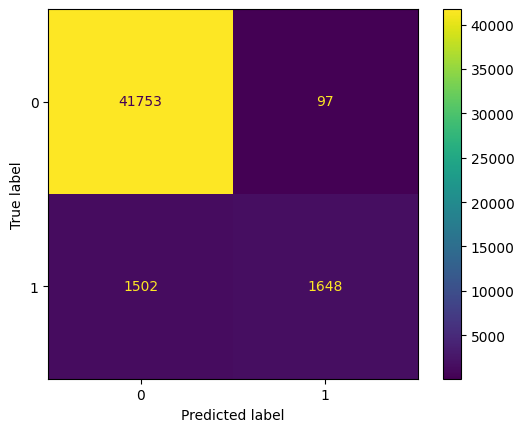

In [ ]:
cm = metrics.confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

In [ ]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred, digits=3))

ROC AUC Score: 0.9639891904192979

Classification Report:
               precision    recall  f1-score   support

           0      0.965     0.998     0.981     41850
           1      0.944     0.523     0.673      3150

    accuracy                          0.964     45000
   macro avg      0.955     0.760     0.827     45000
weighted avg      0.964     0.964     0.960     45000



# Random Forest

In [ ]:
# %%time

# cv_params = {
#     'max_depth': [2],
#     'min_samples_leaf': [1],
#     'min_samples_split': [2],
#     'max_features': [2],
#     'n_estimators': [100]
# }

# rf = RandomForestClassifier(random_state=42)
# scoring = ['accuracy', 'recall']
# split_index = [0 if x in X_test_scaled.index else -1 for x in X_train_scaled.index]
# custom_split = PredefinedSplit(split_index)
# grid_search = GridSearchCV(estimator=rf, param_grid=cv_params, scoring=scoring, refit='recall', cv=custom_split)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred_rf, digits=3))

ROC AUC Score: 0.9639614723786767

Classification Report:
               precision    recall  f1-score   support

           0      0.966     0.999     0.982     41850
           1      0.968     0.530     0.685      3150

    accuracy                          0.966     45000
   macro avg      0.967     0.764     0.833     45000
weighted avg      0.966     0.966     0.961     45000



## XGBoost

In [ ]:
xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=13.29,
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

# Predict & Evaluate
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("🎯 ROC AUC Score:", metrics.roc_auc_score(y_test, y_prob_xgb))
print("\n📋 Classification Report:\n", metrics.classification_report(y_test, y_pred_xgb, digits=3))

NameError: name 'xgb' is not defined

In [ ]:
plot_importance(xgb_model.best_estimator_)

NameError: name 'plot_importance' is not defined

Best recall, accuracy out of these models

Why recall, accuracy?



Cancellations are high when VTAT is high
Driver reblancing on pickup locations which has high VTAT as high VTAT is the greatest contributor to customer cancellations.